In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score, average_precision_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# 1. Synthesize Imbalanced Fraud Dataset
np.random.seed(42)
n_legit = 99000
n_fraud = 1000  # ~1% positive class

legit_data = np.random.normal(loc=0, scale=1, size=(n_legit, 10))
fraud_data = np.random.normal(loc=1.5, scale=1.5, size=(n_fraud, 10))

X = np.vstack([legit_data, fraud_data])
y = np.hstack([np.zeros(n_legit), np.ones(n_fraud)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Compute Imbalance Ratio
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

In [5]:
# Instantiate and train XGBoost with scale_pos_weight
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    use_label_encoder=False,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predict probabilities and classes
y_probs = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= 0.5).astype(int)

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [19:37:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC Score: 0.9955
PR-AUC (Average Precision) Score: 0.9251

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     19800
         1.0       0.82      0.88      0.85       200

    accuracy                           1.00     20000
   macro avg       0.91      0.94      0.92     20000
weighted avg       1.00      1.00      1.00     20000



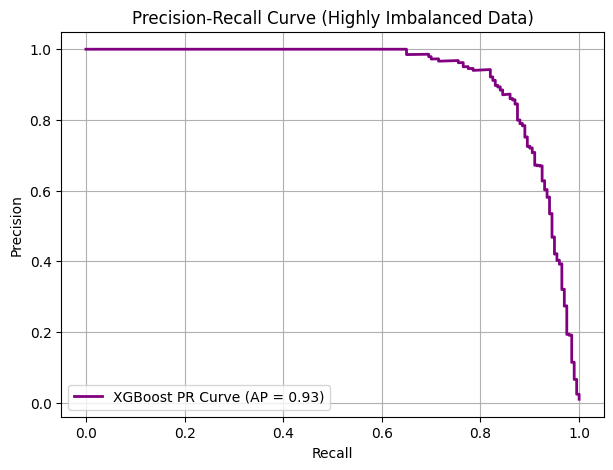

In [ ]:
# Evaluation Metrics
roc_auc = roc_auc_score(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC (Average Precision) Score: {pr_auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Precision-Recall Curve Plot
precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'XGBoost PR Curve (AP = {pr_auc:.2f})', color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Highly Imbalanced Data)')
plt.legend()
plt.grid(True)
plt.show()